In [1]:
import numpy as np
import matplotlib.pyplot as plt
from core.greeks import delta

## Scenario A — General Collateral vs Hard-to-Borrow

General Collateral refers to stocks that are easy to borrow where the borrow rate is 
essentially zero and anyone can short them freely. Hard-to-borrow stocks are names where 
lenders are scarce and the borrow rate can reach 10, 20 or even 50 percent annually.

At 15% borrow the entire delta curve shifts right and compresses downward. A stock trading 
at 120 with a GC borrow has a delta near 0.95 — essentially a fully hedged position. The 
same stock with a 15% borrow has a delta closer to 0.60. That is a 35 point gap on a single 
name, meaning you would be holding 35 fewer shares in your hedge than you should.

In [15]:
S_range = np.linspace(40, 200, 200)
K = 100
r = 0.05
q = 0.02
sigma = 0.20
T = 1.0

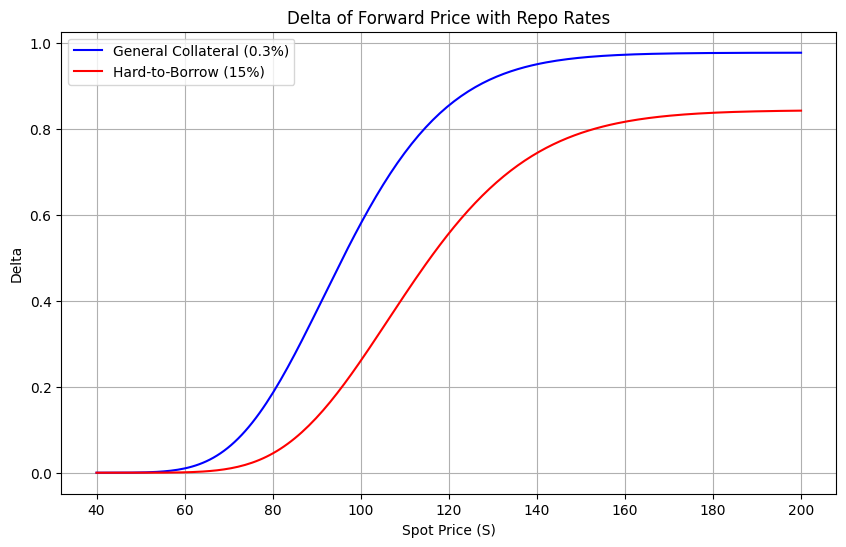

In [17]:
rho_general_colateral = 0.003
rho_hard_to_borrow = 0.15

delta_gc  = delta(S_range, K, r, q, rho_general_colateral,  T, sigma)
delta_htb = delta(S_range, K, r, q, rho_hard_to_borrow, T, sigma)

plt.figure(figsize=(10, 6))
plt.plot(S_range, delta_gc, label='General Collateral (0.3%)', color='blue')
plt.plot(S_range, delta_htb, label='Hard-to-Borrow (15%)', color='red')
plt.title('Delta of Forward Price with Repo Rates')
plt.xlabel('Spot Price (S)')
plt.ylabel('Delta')
plt.legend()
plt.grid()
plt.show()

## Scenario B — Short Squeeze overnight

When a short squeeze hits, lenders pull their stock and everyone wants to borrow at the 
same time. The borrow rate explodes because there is simply no supply left at any 
reasonable price.

In our example the repo goes from 2% to 80% overnight. The forward collapses and the 
delta drops from 0.52 to 0.02. A position that was delta neutral at the close is now 
carrying 5,000 shares of unwanted long delta on a 10,000 share notional before the 
market even opens. That entire position needs to be unwound at the fixing . 

In [19]:
S =100
K = 100
T = 0.25

rho_before = 0.02
rho_after = 0.8

delta_before = delta(S, K, r, q, rho_before, T, sigma)
delta_after = delta(S, K, r, q, rho_after, T, sigma)

diff = delta_after - delta_before

In [20]:
print(f"Delta before squeeze : {delta_before:.4f}")
print(f"Delta after squeeze  : {delta_after:.4f}")
print(f"Delta shift          : {diff:.4f}")
print(f"Shares to re-hedge (per 100 shares notional) : {diff * 100:.1f}")
print(f"Shares to re-hedge (per 10,000 shares notional) : {diff * 10000:.0f}")

Delta before squeeze : 0.5246
Delta after squeeze  : 0.0248
Delta shift          : -0.4999
Shares to re-hedge (per 100 shares notional) : -50.0
Shares to re-hedge (per 10,000 shares notional) : -4999


## Scenario C — Closing auction

The repo spikes overnight from 2% to 15% on a near-term ITM call. The delta shifts from 
0.87 to 0.83, leaving 387 shares of excess long delta on a 10,000 share notional. Those 
get sold at the closing auction to restore a flat book before the next open.

The move is contained here because the option is short dated, T is small so the forward 
does not drift far even with a meaningful repo move. On a 1 or 2 year option the same 
spike would shift the delta by 20 to 30 points, turning a routine end of day rebalancing 
into a significant position adjustment at the fixing.

In [27]:
S = 105
K = 100
T = 0.05
notional = 10000

rho_before = 0.02
rho_after  = 0.15

delta_before = delta(S, K, r, q, rho_before, T, sigma)
delta_after  = delta(S, K, r, q, rho_after,  T, sigma)

delta_shift  = delta_after - delta_before
shares_to_trade = delta_shift * notional

print(f"Delta before repo spike  : {delta_before:.4f}")
print(f"Delta after repo spike   : {delta_after:.4f}")
print(f"Delta shift              : {delta_shift:.4f}")
print(f"Shares to trade at close : {shares_to_trade:.0f}")

if shares_to_trade < 0:
    print(f"Action : SELL {abs(shares_to_trade):.0f} shares at the closing auction")
else:
    print(f"Action : BUY {shares_to_trade:.0f} shares at the closing auction")

Delta before repo spike  : 0.8679
Delta after repo spike   : 0.8292
Delta shift              : -0.0387
Shares to trade at close : -387
Action : SELL 387 shares at the closing auction
